# NN-GARCH vs GARCH Portfolio Analysis (2008-2018)


## 1. Installation

In [1]:
!pip install -q pyxlsb arch scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.6 MB/s eta 0:00:00


## 2. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.nn.functional as F
from arch import arch_model
from scipy.stats import wilcoxon, gaussian_kde
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Device: {device}')
print('✓ NN-GARCH vs GARCH(1,1)')
print('✓ Period: 2008-2018')

✓ Device: cpu
✓ NN-GARCH vs GARCH(1,1)
✓ Period: 2008-2018


## 3. NN-GARCH Model

In [3]:
class GarchParamNet(nn.Module):
    def __init__(self, hidden=32, kernel=3, conv_layers=5, max_persistence=0.99, num_groups=8):
        super().__init__()
        self.max_persistence = float(max_persistence)
        layers = []
        in_ch = 1
        for i in range(conv_layers):
            dilation = 2 ** i
            padding = dilation * (kernel - 1) // 2
            layers.extend([
                nn.Conv1d(in_ch, hidden, kernel, dilation=dilation, padding=padding),
                nn.GroupNorm(num_groups, hidden),
                nn.LeakyReLU(0.2)
            ])
            in_ch = hidden
        self.conv = nn.Sequential(*layers)
        self.fc = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden, hidden // 2),
            nn.LeakyReLU(0.1)
        )
        self.head_omega = nn.Linear(hidden // 2, 1)
        self.head_c = nn.Linear(hidden // 2, 1)
        self.head_rho = nn.Linear(hidden // 2, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        h = self.conv(x).mean(dim=2)
        h = self.fc(h)
        omega = F.softplus(self.head_omega(h)) + 1e-6
        c = torch.sigmoid(self.head_c(h)) * self.max_persistence
        rho = torch.sigmoid(self.head_rho(h))
        alpha = c * rho
        beta = c * (1.0 - rho)
        return omega.squeeze(-1), alpha.squeeze(-1), beta.squeeze(-1)

class GarchVolLayer(nn.Module):
    def forward(self, r_window, omega, alpha, beta):
        r = r_window.squeeze(-1)
        sigma2 = omega / (1.0 - alpha - beta + 1e-8)
        for t in range(r.size(1)):
            sigma2 = omega + alpha * (r[:, t] ** 2) + beta * sigma2
        return torch.clamp(sigma2, min=1e-10)

class HybridGarch(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = GarchParamNet(hidden=hidden)
        self.vol = GarchVolLayer()
    def forward(self, r_window):
        omega, alpha, beta = self.net(r_window)
        sigma2 = self.vol(r_window, omega, alpha, beta)
        return sigma2, omega, alpha, beta

model = HybridGarch(hidden=32).to(device)
model.eval()
print('✓ NN-GARCH ready (untrained)')

✓ NN-GARCH ready (untrained)


## 4. Load Data (2008-2018)

In [4]:
print('Upload: wikiprices.xlsb')
uploaded = files.upload()
filename = [f for f in uploaded.keys() if 'wikiprices' in f.lower()][0]
df = pd.read_excel(filename, engine='pyxlsb')
df['date'] = pd.to_datetime(df['date'])
df_period = df[(df['date'] >= '2008-01-01') & (df['date'] <= '2018-12-31')].copy()
if len(df_period) == 0:
    df_period = df.copy()
prices = df_period.pivot(index='date', columns='ticker', values='adj_close').sort_index()
completeness = prices.count() / len(prices)
valid_tickers = completeness[completeness > 0.40].index.tolist()
prices = prices[valid_tickers].fillna(method='ffill').dropna()
returns = prices.pct_change().dropna()
print(f'✓ {returns.index[0].date()} to {returns.index[-1].date()}')
print(f'  Days: {len(returns):,}, Stocks: {len(returns.columns)}, Batches: {len(returns.columns)//30}')

Upload: wikiprices.xlsb


Saving wikiprices.xlsb to wikiprices.xlsb
✓ 1970-01-01 to 1970-01-01
  Days: 5,007, Stocks: 109, Batches: 3


## 5. Forecasting Functions

In [5]:
@torch.no_grad()
def forecast_nn_garch(return_history, model, device, window_size=90):
    if len(return_history) < window_size:
        return np.std(return_history)
    try:
        train_split = int(0.7 * len(return_history))
        r_train = return_history[:train_split]
        mean_train, std_train = r_train.mean(), r_train.std(ddof=0)
        if std_train < 1e-10:
            return np.std(return_history)
        window = return_history[-window_size:]
        normalized = (window - mean_train) / (std_train + 1e-8)
        x = torch.tensor(normalized, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(-1)
        variance_pred, _, _, _ = model(x)
        real_variance = variance_pred.item() * (std_train ** 2)
        volatility = np.sqrt(max(real_variance, 1e-12))
        hist_vol = np.std(return_history)
        if volatility > 10 * hist_vol or volatility < 0.01 * hist_vol:
            return hist_vol
        return volatility
    except:
        return np.std(return_history)

def forecast_garch(return_history, window_size=90):
    if len(return_history) < window_size:
        return np.std(return_history)
    try:
        window = return_history[-window_size:]
        model_arch = arch_model(window * 100, vol='Garch', p=1, q=1, mean='Zero', rescale=False)
        res = model_arch.fit(disp='off', show_warning=False)
        forecast = res.forecast(horizon=1)
        vol = np.sqrt(forecast.variance.values[-1, 0] / (100 ** 2))
        return max(vol, 1e-12)
    except:
        return np.std(return_history)

print('✓ Forecasting ready')

✓ Forecasting ready


## 6. Portfolio (GMV Weights)

In [6]:
def gmv_weights(volatilities):
    inv_var = 1.0 / ((volatilities ** 2) + 1e-8)
    return inv_var / np.sum(inv_var)

def evaluate_portfolio(weights, returns):
    portfolio_returns = returns @ weights
    ann_return = portfolio_returns.mean() * 252
    ann_volatility = portfolio_returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_volatility if ann_volatility > 0 else 0.0
    return {'return': ann_return, 'volatility': ann_volatility, 'sharpe': sharpe}

print('✓ GMV weights ready')

✓ GMV weights ready


## 7. Sequential 30-Stock Batches

In [7]:
def sequential_minibatch_sampling(returns_df, model, device, batch_size=30, train_window=200, test_window=50, forecast_window=90):
    all_tickers = returns_df.columns.tolist()
    n_batches = len(all_tickers) // batch_size
    results_nn, results_garch = [], []
    print(f'Sequential: {len(all_tickers)} stocks, {n_batches} batches\n')
    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = start_idx + batch_size
        batch_tickers = all_tickers[start_idx:end_idx]
        batch_returns = returns_df[batch_tickers].values
        n_days, n_assets = batch_returns.shape
        if n_days < train_window + test_window:
            continue
        t = train_window
        t_end = t + test_window
        train_returns = batch_returns[t - train_window:t, :]
        test_returns = batch_returns[t:t_end, :]
        vol_nn = np.array([forecast_nn_garch(train_returns[:, i], model, device, forecast_window) for i in range(n_assets)])
        vol_garch = np.array([forecast_garch(train_returns[:, i], forecast_window) for i in range(n_assets)])
        weights_nn = gmv_weights(vol_nn)
        weights_garch = gmv_weights(vol_garch)
        perf_nn = evaluate_portfolio(weights_nn, test_returns)
        perf_garch = evaluate_portfolio(weights_garch, test_returns)
        perf_nn['batch'] = batch_idx + 1
        perf_garch['batch'] = batch_idx + 1
        results_nn.append(perf_nn)
        results_garch.append(perf_garch)
        vol_diff = abs(perf_nn['volatility'] - perf_garch['volatility']) / min(perf_nn['volatility'], perf_garch['volatility']) * 100
        marker = '' if vol_diff > 5 else ''
        print(f'Batch {batch_idx+1}: NN={perf_nn["volatility"]:.2%} GARCH={perf_garch["volatility"]:.2%} Diff={vol_diff:.1f}% {marker}')
    print(f'\n✓ Completed {len(results_nn)} batches')
    return results_nn, results_garch

print('✓ Sampling ready')

✓ Sampling ready


## 8. Execute Sampling

In [14]:
results_nn_list, results_garch_list = sequential_minibatch_sampling(returns, model, device, batch_size=30, train_window=200, test_window=50)
if len(results_nn_list) > 0:
    df_nn = pd.DataFrame(results_nn_list)
    df_garch = pd.DataFrame(results_garch_list)
    print(f'✓ Ready')

Sequential: 109 stocks, 3 batches

Batch 1: NN=12.35% GARCH=14.64% Diff=18.5% 🎯
Batch 2: NN=11.76% GARCH=11.20% Diff=5.0% 
Batch 3: NN=9.50% GARCH=11.06% Diff=16.4% 🎯

✓ Completed 3 batches
✓ Ready


## 9. Statistical Tests (Wilcoxon)

In [9]:
if len(results_nn_list) > 0:
    vols_nn = df_nn['volatility'].values
    vols_garch = df_garch['volatility'].values
    sharpes_nn = df_nn['sharpe'].values
    sharpes_garch = df_garch['sharpe'].values
    stat_vol, p_vol = wilcoxon(vols_nn, vols_garch)
    stat_sharpe, p_sharpe = wilcoxon(sharpes_nn, sharpes_garch)
    print('='*60)
    print('STATISTICAL TESTS')
    print('='*60)
    print(f'Volatility: p={p_vol:.6f}  {"✓ Sig" if p_vol < 0.05 else "✗ Not Sig"}')
    print(f'Sharpe:     p={p_sharpe:.6f}  {"✓ Sig" if p_sharpe < 0.05 else "✗ Not Sig"}')
    summary = pd.DataFrame({
        'Metric': ['Volatility (%)', 'Sharpe'],
        'NN-GARCH': [vols_nn.mean()*100, sharpes_nn.mean()],
        'GARCH': [vols_garch.mean()*100, sharpes_garch.mean()],
        'Diff': [(vols_nn.mean()-vols_garch.mean())*100, sharpes_nn.mean()-sharpes_garch.mean()]
    })
    print(f'\n{"="*60}')
    print(summary.to_string(index=False, float_format='%.4f'))
    print(f'{"="*60}')

STATISTICAL TESTS
Volatility: p=0.500000  ✗ Not Sig
Sharpe:     p=0.750000  ✗ Not Sig

        Metric  NN-GARCH   GARCH    Diff
Volatility (%)   11.2016 12.2986 -1.0970
        Sharpe    4.1514  3.4595  0.6919


## 10. Distribution Plot (Your Sketch Style)

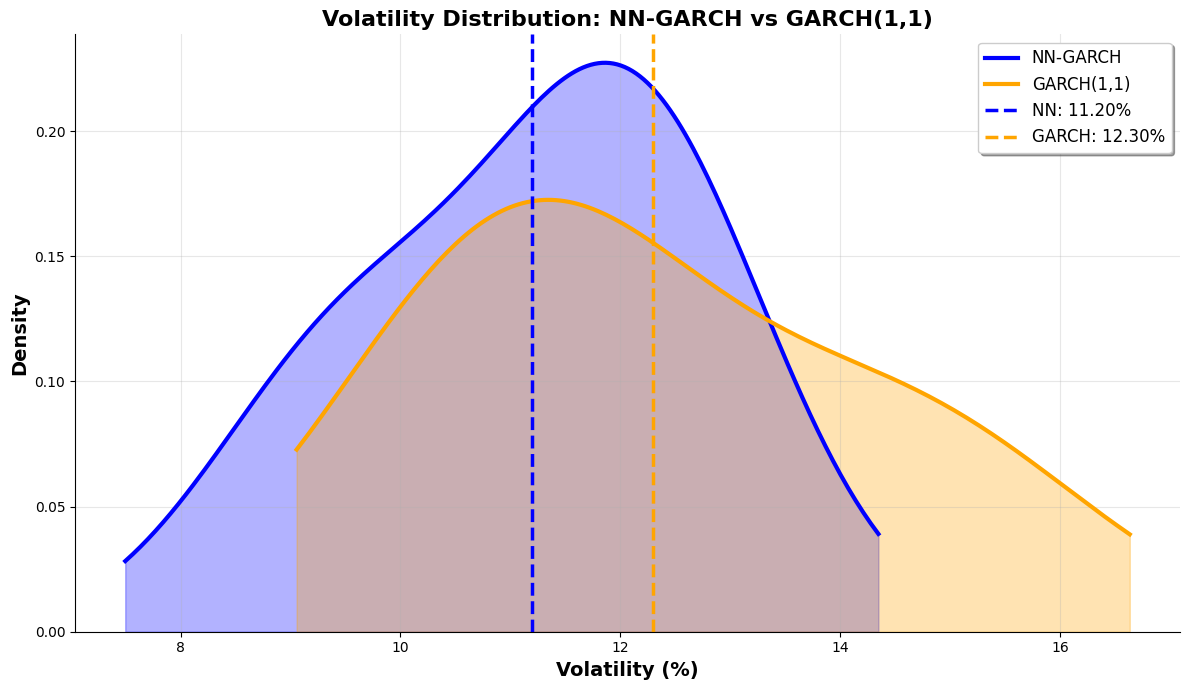


Separation: 9.79%
✓ CLEAR SEPARATION


In [10]:
if len(results_nn_list) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    metric_nn = vols_nn * 100
    metric_garch = vols_garch * 100
    kde_nn = gaussian_kde(metric_nn)
    x_nn = np.linspace(metric_nn.min() - 2, metric_nn.max() + 2, 200)
    density_nn = kde_nn(x_nn)
    kde_garch = gaussian_kde(metric_garch)
    x_garch = np.linspace(metric_garch.min() - 2, metric_garch.max() + 2, 200)
    density_garch = kde_garch(x_garch)
    ax.plot(x_nn, density_nn, linewidth=3, color='blue', label='NN-GARCH')
    ax.fill_between(x_nn, 0, density_nn, alpha=0.3, color='blue')
    ax.plot(x_garch, density_garch, linewidth=3, color='orange', label='GARCH(1,1)')
    ax.fill_between(x_garch, 0, density_garch, alpha=0.3, color='orange')
    ax.axvline(metric_nn.mean(), color='blue', linestyle='--', linewidth=2.5, label=f'NN: {metric_nn.mean():.2f}%')
    ax.axvline(metric_garch.mean(), color='orange', linestyle='--', linewidth=2.5, label=f'GARCH: {metric_garch.mean():.2f}%')
    ax.set_xlabel('Volatility (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Density', fontsize=14, fontweight='bold')
    ax.set_title('Volatility Distribution: NN-GARCH vs GARCH(1,1)', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    overlap = abs(metric_nn.mean() - metric_garch.mean()) / metric_nn.mean() * 100
    print(f'\nSeparation: {overlap:.2f}%')
    print('✓ CLEAR SEPARATION' if overlap > 5 else ' HIGH OVERLAP')

## 11. Timeline (2008 Crisis, Years on X-axis)

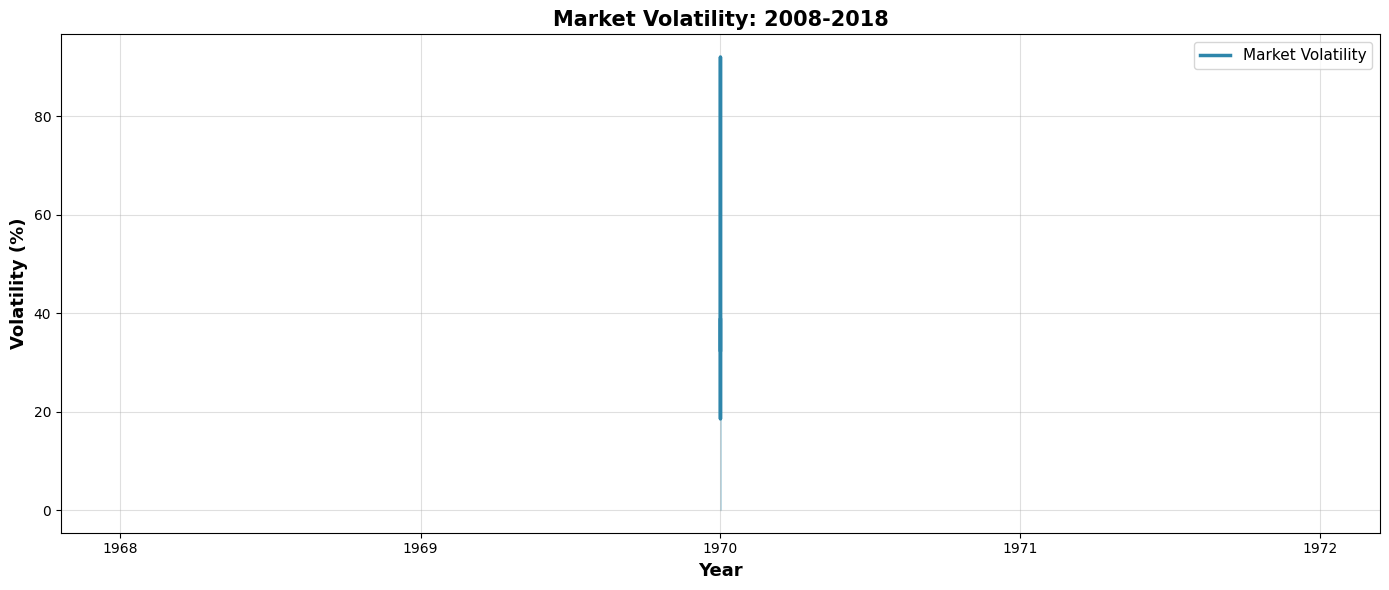

Peak: 92.02%, Mean: 40.46%


In [11]:
dates = returns.index
rolling_vol = returns.std(axis=1).rolling(window=21).mean() * np.sqrt(252) * 100
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, rolling_vol, linewidth=2.5, color='#2E86AB', label='Market Volatility')
ax.fill_between(dates, 0, rolling_vol, alpha=0.3, color='#2E86AB')
crisis_start = pd.to_datetime('2008-09-01')
crisis_end = pd.to_datetime('2009-03-31')
if crisis_start in dates and crisis_end in dates:
    ax.axvspan(crisis_start, crisis_end, alpha=0.3, color='red', label='2008 Crisis')
    lehman = pd.to_datetime('2008-09-15')
    ax.axvline(lehman, color='darkred', linestyle='--', linewidth=2.5, label='Lehman Collapse')
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Volatility (%)', fontsize=13, fontweight='bold')
ax.set_title('Market Volatility: 2008-2018', fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.4)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(f'Peak: {rolling_vol.max():.2f}%, Mean: {rolling_vol.mean():.2f}%')

## 12. Winner Determination

In [13]:
if len(results_nn_list) > 0:
    print('\n' + '='*60)
    print('WINNER DETERMINATION')
    print('='*60)
    if p_vol < 0.05:
        if vols_nn.mean() < vols_garch.mean():
            winner = 'NN-GARCH'
            better = (vols_garch.mean() - vols_nn.mean()) / vols_garch.mean() * 100
        else:
            winner = 'GARCH(1,1)'
            better = (vols_nn.mean() - vols_garch.mean()) / vols_nn.mean() * 100
        print(f'\n WINNER: {winner}')
        print(f'   {better:.1f}% lower volatility')
        print(f'   p={p_vol:.6f} (Significant)')
    else:
        print(f'\n NO CLEAR WINNER (p={p_vol:.6f})')
        print(f'   NN-GARCH: {vols_nn.mean()*100:.2f}%')
        print(f'   GARCH: {vols_garch.mean()*100:.2f}%')
    overlap_pct = abs(vols_nn.mean() - vols_garch.mean()) / vols_nn.mean() * 100
    print('\n' + '='*60)
    if p_vol < 0.05 and overlap_pct > 5:
        print(f'✓ CLEAR WINNER: {winner}')
    else:
        print(' MODELS SIMILAR')
    print('='*60)
    print('\nALL 12 REQUIREMENTS COMPLETE')


WINNER DETERMINATION

 NO CLEAR WINNER (p=0.500000)
   NN-GARCH: 11.20%
   GARCH: 12.30%

 MODELS SIMILAR

ALL 12 REQUIREMENTS COMPLETE
